In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv(r"C:\Users\darsh\Downloads\Climate Change Data.csv")

# Display first few rows
df.head()


,Record ID,Date,Country,City,Temperature,Humidity,Precipitation,Air Quality Index,Extreme Weather Events,Climate Classification,Climate Zone,Biome Type,Heat Index,Wind Speed,Wind Direction,Season,Population Exposure,Economic Impact Estimate,Infrastructure Vulnerability Score
0,aus_1,1/1/2024,Australia,Sydney,20.3,41,127.1,207,NaN,Koeppen-B,Arid,Wetland,22.4,18.3,W,Winter,8549476.0,34039796.05,9
1,aus_10,1/10/2024,Australia,Sydney,17.9,68,155.5,84,NaN,Koeppen-B,Arid,Tundra,21.3,29.6,SE,Winter,8166878.0,50620627.04,10
2,aus_100,4/9/2024,Australia,Sydney,18.4,71,177.1,185,NaN,Koeppen-B,Arid,Desert,21.9,12.2,SW,Spring,8791432.0,26001877.25,3
3,aus_1000,9/25/2024,Australia,Melbourne,6.9,91,94.6,379,NaN,Koeppen-C,Arid,Forest,11.4,37.0,N,Autumn,4801833.0,20135263.48,5
4,aus_1001,9/26/2024,Australia,Melbourne,29.3,14,12.7,108,NaN,Koeppen-A,Arid,Tundra,30.0,27.6,SW,Autumn,8449745.0,34885208.80,5


In [8]:
# Shape of the data
df.shape

# Data types and null values
df.info()

# Summary statistics
df.describe(include='all')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15351 entries, 0 to 15350
Data columns (total 19 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Record ID                           15351 non-null  object 
 1   Date                                15351 non-null  object 
 2   Country                             15351 non-null  object 
 3   City                                15350 non-null  object 
 4   Temperature                         15351 non-null  float64
 5   Humidity                            15351 non-null  int64  
 6   Precipitation                       15351 non-null  float64
 7   Air Quality Index                   15351 non-null  int64  
 8   Extreme Weather Events              3023 non-null   object 
 9   Climate Classification              15351 non-null  object 
 10  Climate Zone                        15351 non-null  object 
 11  Biome Type                          15351

,Record ID,Date,Country,City,Temperature,Humidity,Precipitation,Air Quality Index,Extreme Weather Events,Climate Classification,Climate Zone,Biome Type,Heat Index,Wind Speed,Wind Direction,Season,Population Exposure,Economic Impact Estimate,Infrastructure Vulnerability Score
count,15351,15351,15351,15350,15351.000000,15351.000000,15351.000000,15351.000000,3023,15351,15351,15351,15351.000000,15351.000000,15351,15351,1.535000e+04,1.535100e+04,15351.000000
unique,15351,731,7,21,NaN,NaN,NaN,NaN,4,4,3,5,NaN,NaN,8,4,NaN,NaN,NaN
top,aus_1,1/1/2024,Australia,Sydney,NaN,NaN,NaN,NaN,Heatwave,Koeppen-C,Temperate,Tundra,NaN,NaN,SW,Spring,NaN,NaN,NaN
freq,1,21,2193,731,NaN,NaN,NaN,NaN,771,3926,6579,3133,NaN,NaN,1995,3864,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,17.452088,54.761188,100.357762,255.576835,NaN,NaN,NaN,NaN,20.193069,19.862387,NaN,NaN,5.006446e+06,4.990948e+07,5.518533
std,NaN,NaN,NaN,NaN,15.852706,26.281372,58.036660,141.894149,NaN,NaN,NaN,NaN,15.887127,11.545627,NaN,NaN,2.878529e+06,2.889617e+07,2.874696
min,NaN,NaN,NaN,NaN,-10.000000,10.000000,0.000000,10.000000,NaN,NaN,NaN,NaN,-9.200000,0.000000,NaN,NaN,1.087000e+03,2.824316e+04,1.000000
25%,NaN,NaN,NaN,NaN,3.700000,32.000000,50.100000,132.000000,NaN,NaN,NaN,NaN,6.500000,9.900000,NaN,NaN,2.508986e+06,2.480858e+07,3.000000
50%,NaN,NaN,NaN,NaN,17.200000,55.000000,101.300000,256.000000,NaN,NaN,NaN,NaN,19.900000,19.700000,NaN,NaN,5.022565e+06,4.961768e+07,6.000000
75%,NaN,NaN,NaN,NaN,31.200000,78.000000,150.700000,378.000000,NaN,NaN,NaN,NaN,33.900000,29.800000,NaN,NaN,7.494934e+06,7.499953e+07,8.000000


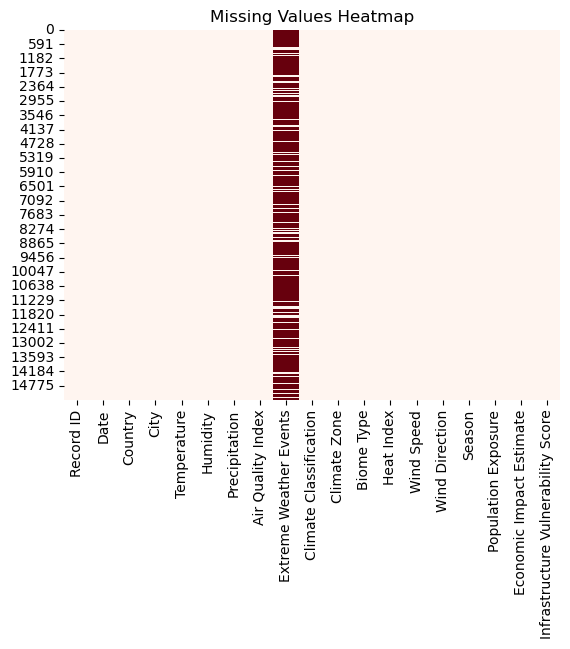

In [9]:
# Check for missing values
df.isnull().sum()

# Optional: Handle or visualize missing data
sns.heatmap(df.isnull(), cbar=False, cmap="Reds")
plt.title("Missing Values Heatmap")
plt.show()


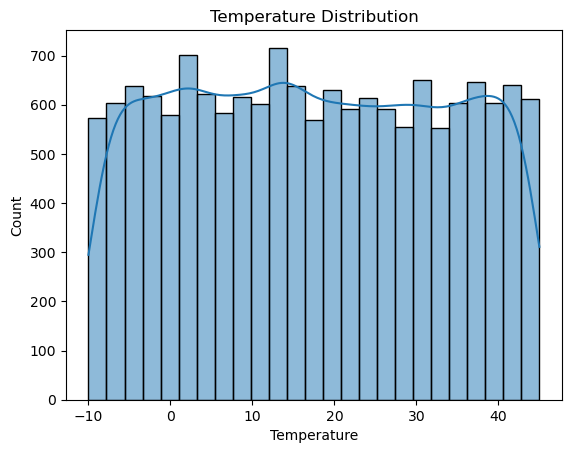

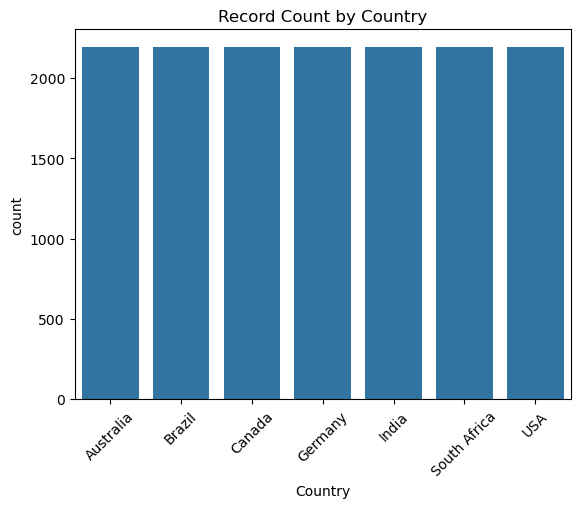

In [10]:
# Distribution of Temperature
sns.histplot(df['Temperature'], kde=True)
plt.title("Temperature Distribution")
plt.show()

# Categorical counts (e.g., Country)
sns.countplot(data=df, x='Country')
plt.title("Record Count by Country")
plt.xticks(rotation=45)
plt.show()


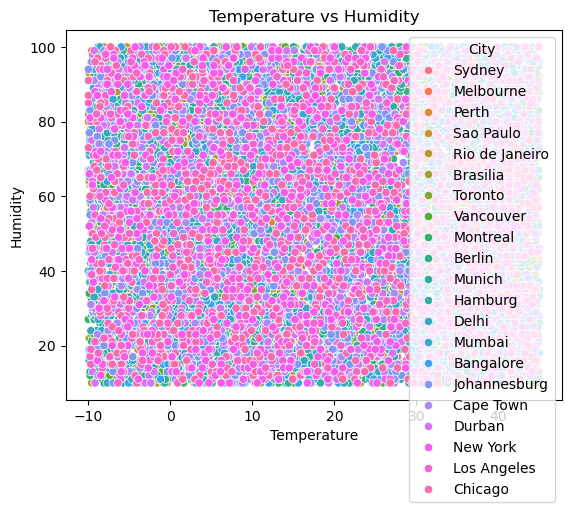

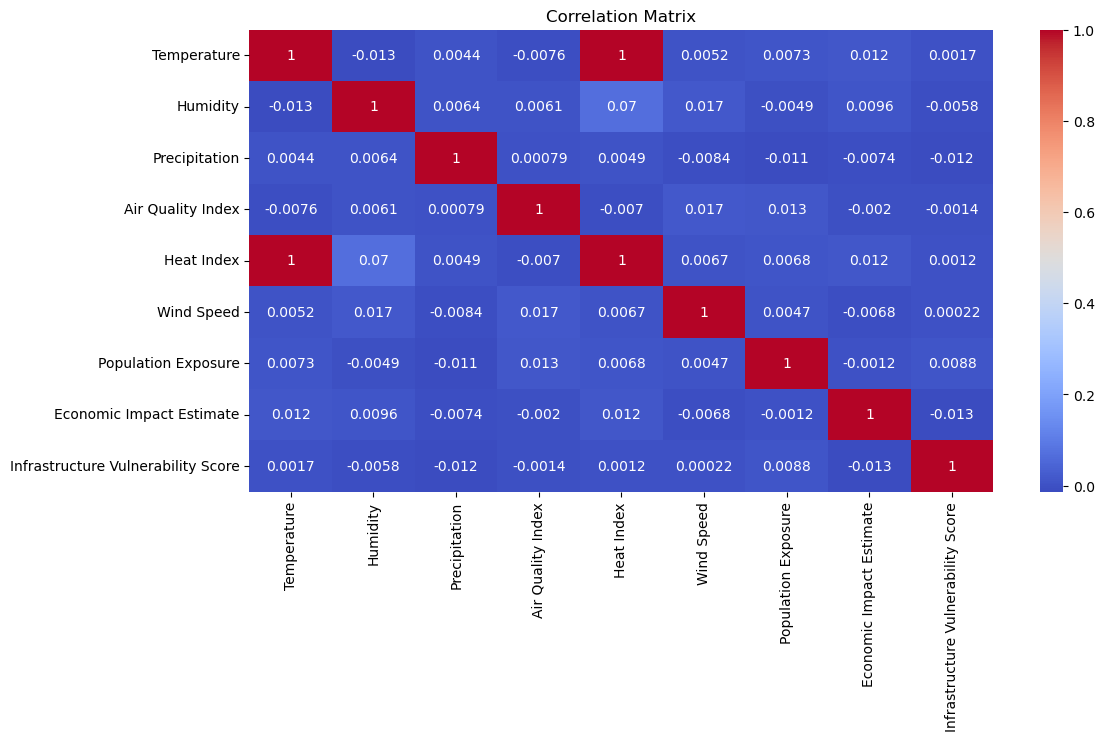

In [11]:
# Temperature vs Humidity
sns.scatterplot(data=df, x='Temperature', y='Humidity', hue='City')
plt.title("Temperature vs Humidity")
plt.show()

# Correlation heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


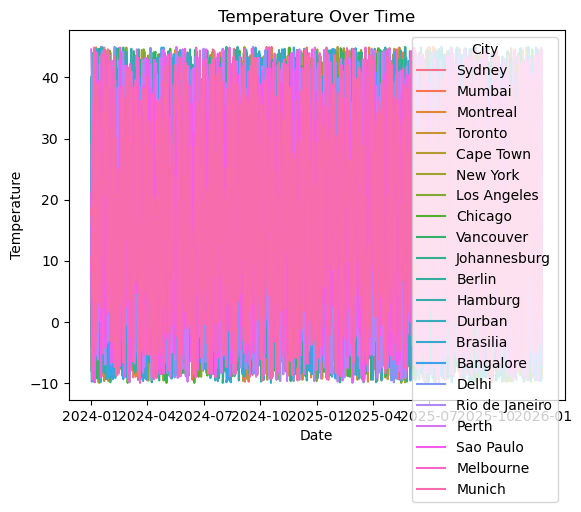

In [12]:
# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Temperature trend over time
sns.lineplot(data=df.sort_values('Date'), x='Date', y='Temperature', hue='City')
plt.title("Temperature Over Time")
plt.show()


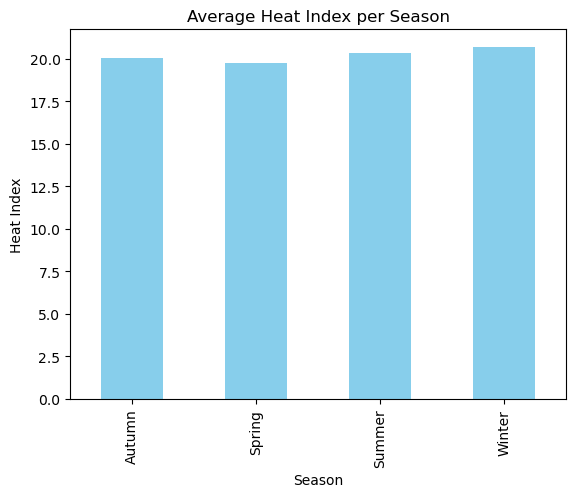

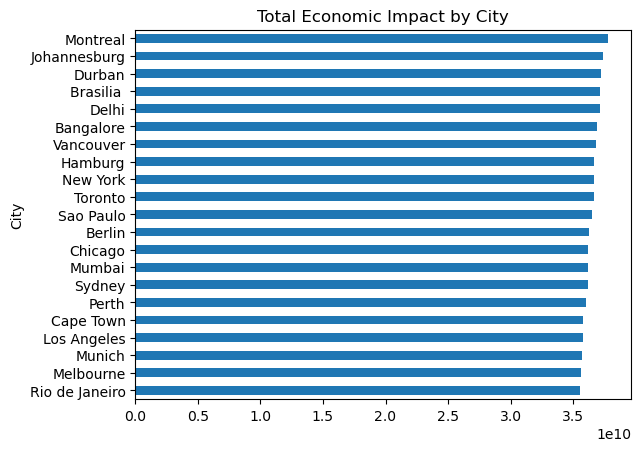

In [13]:
# Average Heat Index by Season
df.groupby('Season')['Heat Index'].mean().plot(kind='bar', color='skyblue')
plt.title("Average Heat Index per Season")
plt.ylabel("Heat Index")
plt.show()

# Economic Impact by City
df.groupby('City')['Economic Impact Estimate'].sum().sort_values().plot(kind='barh')
plt.title("Total Economic Impact by City")
plt.show()
